<a href="https://colab.research.google.com/github/MachineLearnia/Python-Machine-Learning/blob/master/18%20-%20Pandas%20et%20S%C3%A9ries%20Temporelles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 18/30 Pandas et séries temporelles

## 1. Travailler avec des séries Temporelles

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
bitcoin = pd.read_csv("Dataset/BTC-EUR.csv")
bitcoin.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
1,2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2,2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
3,2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
4,2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


In [3]:
bitcoin = pd.read_csv('Dataset/BTC-EUR.csv', index_col='Date', parse_dates=True)
print(bitcoin.head(3))


             Open   High    Low  Close  Adj Close  Volume
Date                                                     
2011-10-04  3.700  3.821  3.746  3.750      3.750    1357
2011-10-05  3.750  3.820  3.650  3.676      3.676    3349
2011-10-06  3.676  3.743  3.450  3.550      3.550    6642


In [4]:
# pd.set_option("display.max_columns", None)  # affiche toutes les colonnes
pd.set_option(
    "display.width", 2000
)  # évite les retours à la ligne
print(bitcoin.tail(3))


                   Open         High          Low        Close    Adj Close       Volume
Date                                                                                    
2019-10-02  7625.560059  7663.270020  7489.770020  7655.250000  7655.250000     51871334
2019-10-03  7655.250000  7685.930176  7379.220215  7516.790039  7516.790039     49437308
2019-10-04  7514.477051  7512.555176  7424.196289  7487.083496  7487.083496  12212041728


In [5]:
btc = bitcoin.reset_index()
btc[:-1]


,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-10-04,3.700000,3.821000,3.746000,3.750000,3.750000,1357
1,2011-10-05,3.750000,3.820000,3.650000,3.676000,3.676000,3349
2,2011-10-06,3.676000,3.743000,3.450000,3.550000,3.550000,6642
3,2011-10-07,3.550000,3.590000,2.900000,3.293000,3.293000,7135
4,2011-10-08,3.293000,3.283000,2.872000,2.890000,2.890000,2007
...,...,...,...,...,...,...,...
2917,2019-09-29,7523.009766,7541.020020,7247.169922,7375.950195,7375.950195,39755968
2918,2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908
2919,2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316
2920,2019-10-02,7625.560059,7663.270020,7489.770020,7655.250000,7655.250000,51871334


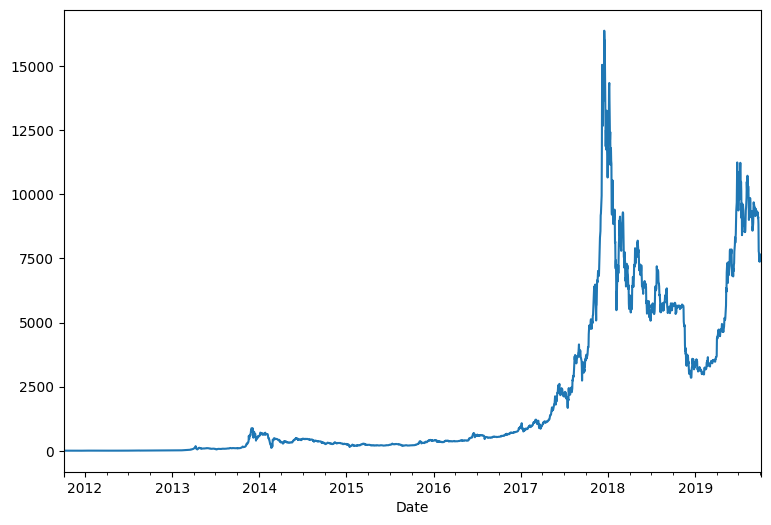

In [6]:
bitcoin["Close"].plot(figsize=(9, 6))
plt.show()


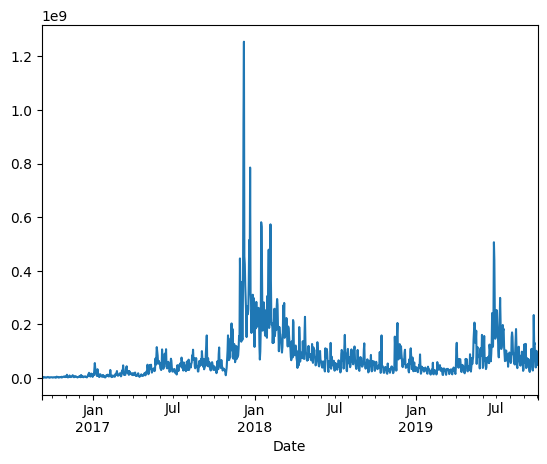

In [7]:
bitcoin["Volume"][1800:-1].plot()
plt.show()


In [8]:
bitcoin.index


DatetimeIndex(['2011-10-04', '2011-10-05', '2011-10-06', '2011-10-07', '2011-10-08', '2011-10-09', '2011-10-10', '2011-10-11', '2011-10-12', '2011-10-13',
               ...
               '2019-09-25', '2019-09-26', '2019-09-27', '2019-09-28', '2019-09-29', '2019-09-30', '2019-10-01', '2019-10-02', '2019-10-03', '2019-10-04'], dtype='datetime64[ns]', name='Date', length=2923, freq=None)

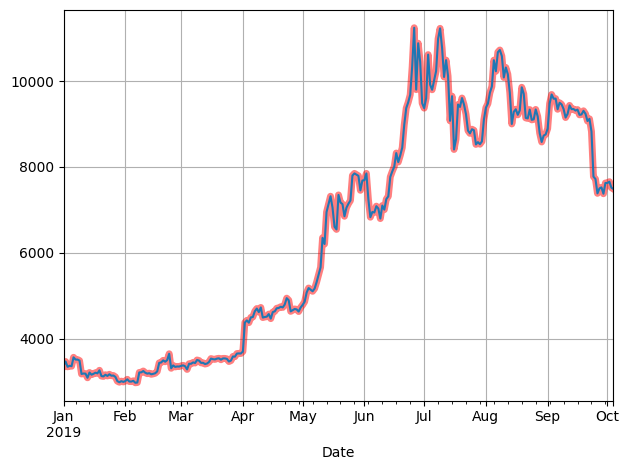

In [9]:
bitcoin.loc['2019','Close'].plot(c='r', linewidth=5, alpha=.5)
# OU
bitcoin.loc['2019']['Close'].plot()
plt.tight_layout()
plt.grid()


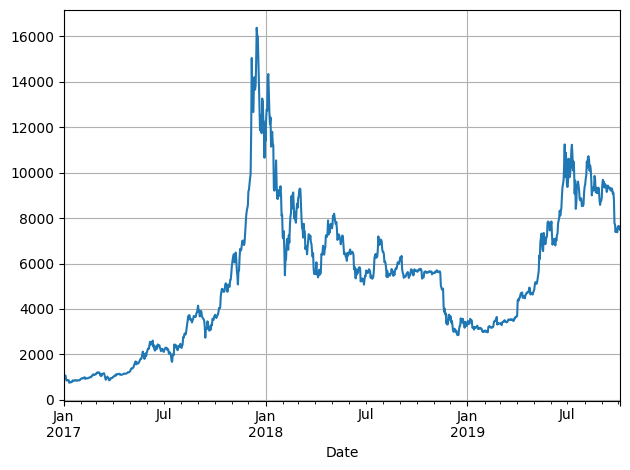

In [10]:
bitcoin.loc['2017':'2019']["Close"].plot()
plt.tight_layout()
plt.grid()


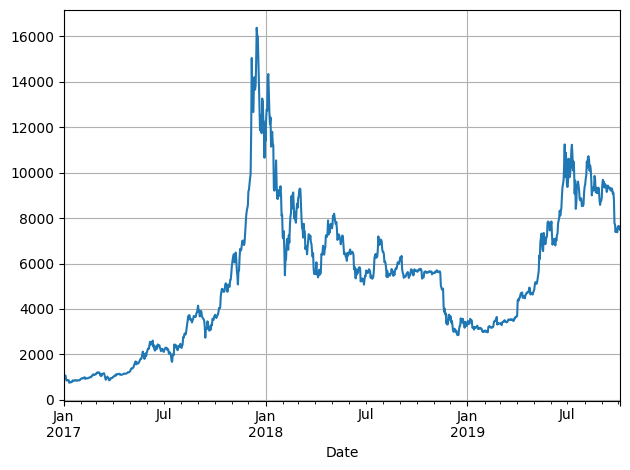

In [11]:
bitcoin["2017":"2019"]["Close"].plot()
plt.tight_layout()
plt.grid()


In [12]:
bitcoin.describe()


,Open,High,Low,Close,Adj Close,Volume
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2.923000e+03
mean,1989.933793,2052.332373,1921.136068,1992.525601,1992.525601,3.310173e+07
std,3007.007836,3112.005967,2881.927756,3008.582222,3008.582222,2.351084e+08
min,1.521000,1.649000,1.500000,1.521000,1.521000,1.470000e+02
25%,107.805001,111.944999,102.465000,108.400002,108.400002,2.756760e+05
50%,399.570007,405.850006,392.000000,399.809998,399.809998,2.049012e+06
75%,3202.104980,3285.430054,3140.775024,3207.844971,3207.844971,3.326155e+07
max,16374.540039,16670.939453,15760.450195,16376.299805,16376.299805,1.221204e+10


## 2. Resample

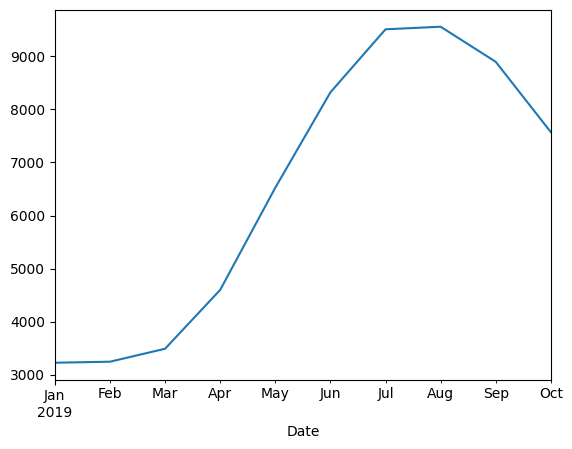

In [13]:
bitcoin.loc['2019', 'Close'].resample('ME').mean().plot()
plt.show()


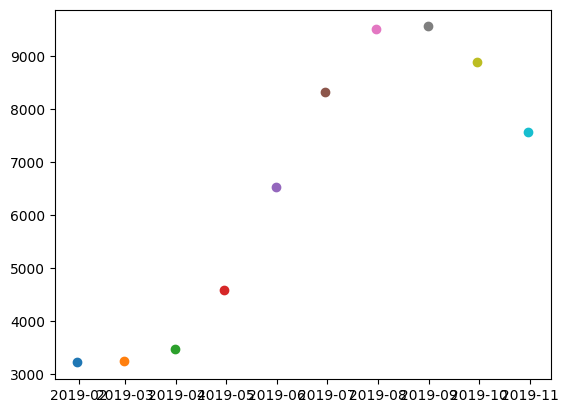

In [14]:
monthly = bitcoin.loc["2019", "Close"].resample("ME").mean()

for i, (date, value) in enumerate(monthly.items()):
    plt.plot(date, value, marker="o", color=plt.cm.tab10(i % 10))  # palette tab10


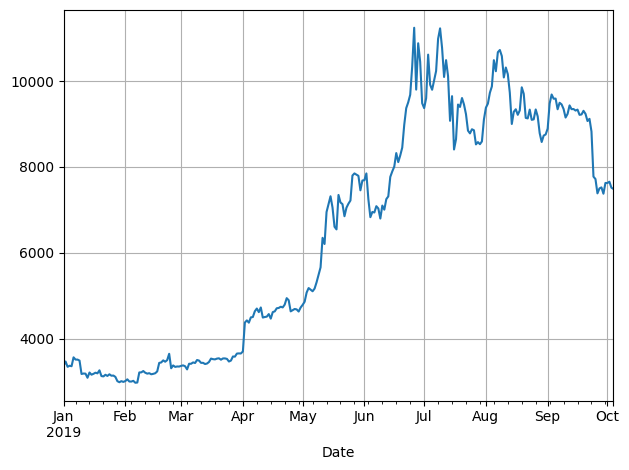

In [15]:
bitcoin["2019":]["Close"].plot()
plt.tight_layout()
plt.grid()


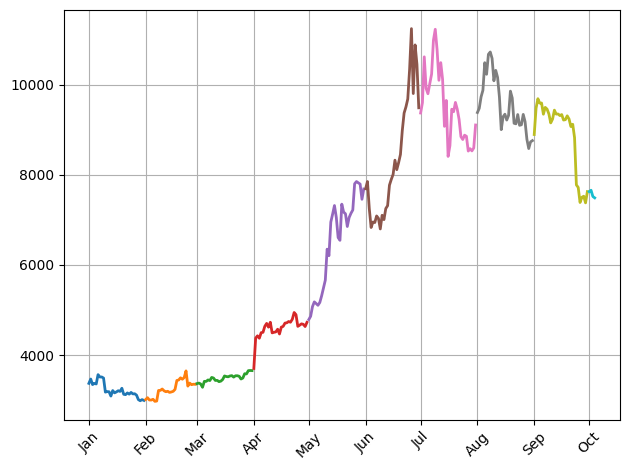

In [16]:
daily = bitcoin.loc["2019":, "Close"]

for i, (month, segment) in enumerate(daily.groupby(daily.index.month)):
    plt.plot(segment.index, segment.values, color=plt.cm.tab10(i % 10), linewidth=2)

plt.xticks(
    ticks=monthly.index.to_period("M").to_timestamp(),
    labels=monthly.index.strftime("%b"),  # noms abrégés des mois
    rotation=45,
)
plt.grid()
plt.tight_layout()


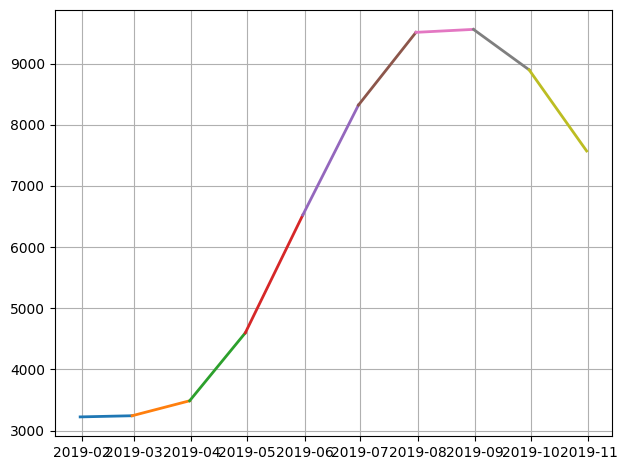

In [17]:
monthly = bitcoin.loc["2019", "Close"].resample("ME").mean()

# Boucler sur les paires de points consécutifs
for i in range(len(monthly) - 1):
    x = [monthly.index[i], monthly.index[i + 1]]
    y = [monthly.values[i], monthly.values[i + 1]]
    plt.plot(x, y, color=plt.cm.tab10(i % 10), linewidth=2)

plt.grid()
plt.tight_layout()


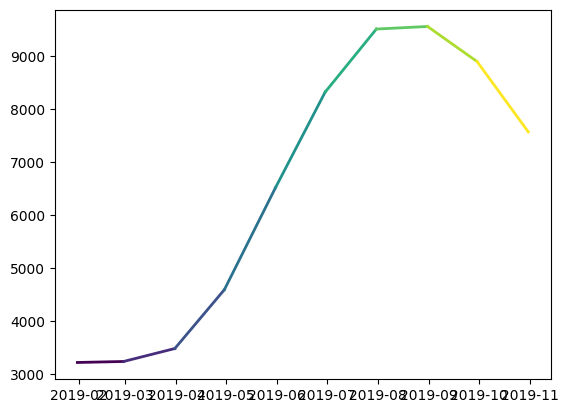

In [18]:
colors = plt.cm.viridis(np.linspace(0, 1, len(monthly) - 1))
for i in range(len(monthly) - 1):
    plt.plot(
        monthly.index[i : i + 2],
        monthly.values[i : i + 2],
        color=colors[i],
        linewidth=2,
    )


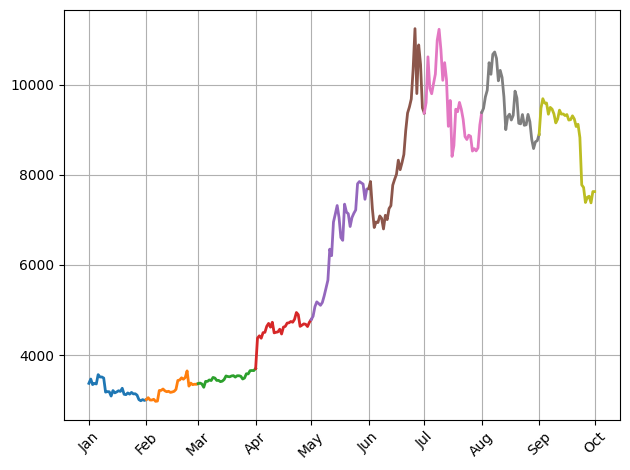

In [19]:
# Série journalière
daily = bitcoin.loc["2019", "Close"]

# Série mensuelle (pour récupérer les bornes et couleurs)
monthly = daily.resample("MS").mean()

# Boucler sur chaque mois
for i in range(len(monthly)-1):
    start = monthly.index[i]
    end = monthly.index[i+1]
    segment = daily.loc[start:end]  # sous-série journalière
    plt.plot(segment.index, segment.values, color=plt.cm.tab10(i % 10), linewidth=2)
    
plt.xticks(
    ticks=monthly.index.to_period("M").to_timestamp(),
    labels=monthly.index.strftime("%b"),
    rotation=45,
)
plt.grid()
plt.tight_layout()


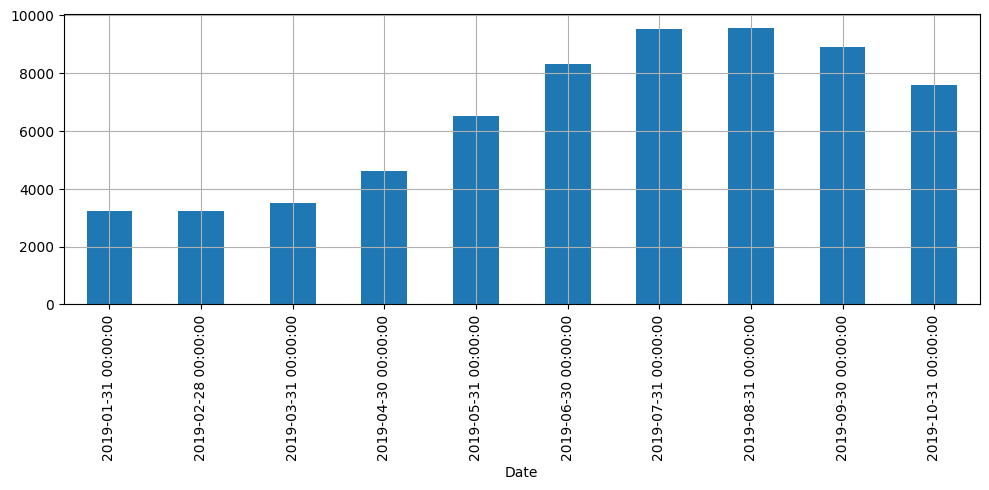

In [20]:
monthly = bitcoin.loc["2019", "Close"].resample("ME").mean()

monthly.plot(kind="bar", colormap="tab20", figsize=(10, 5))
plt.tight_layout()
plt.grid()


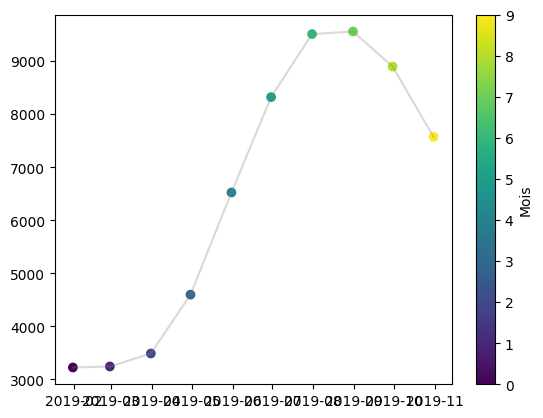

In [21]:
monthly = bitcoin.loc["2019", "Close"].resample("ME").mean()

plt.scatter(monthly.index, monthly.values, c=range(len(monthly)), cmap="viridis")
plt.plot(monthly.index, monthly.values, alpha=0.3, color="gray")  # relier les points
plt.colorbar(label="Mois")


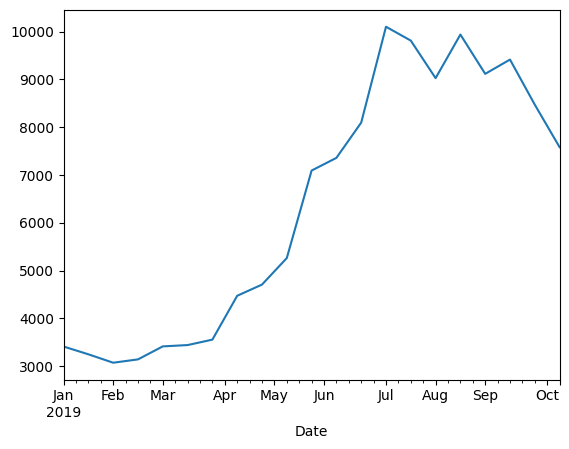

In [22]:
bitcoin.loc['2019', 'Close'].resample('2W').mean().plot()
plt.show()


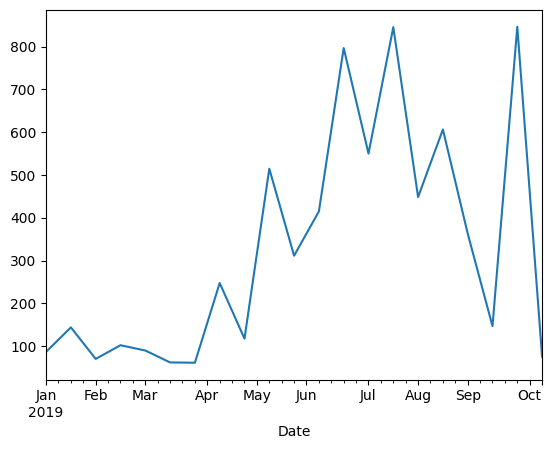

In [23]:
bitcoin.loc['2019', 'Close'].resample('2W').std().plot()
plt.show()


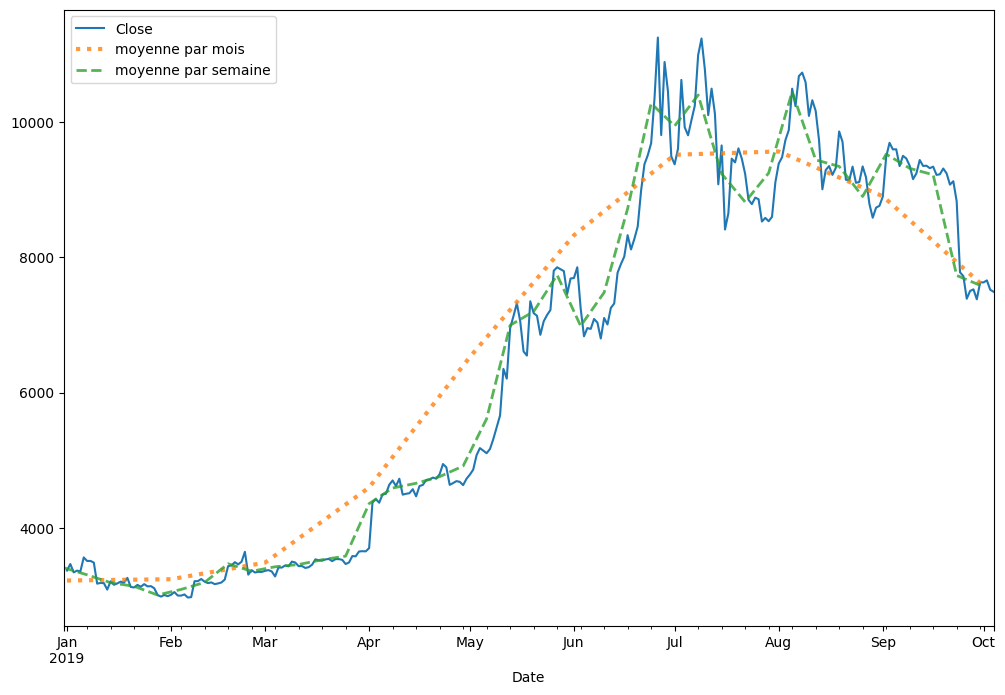

In [24]:
plt.figure(figsize=(12, 8))
bitcoin.loc['2019', 'Close'].plot()
bitcoin.loc['2019', 'Close'].resample('ME').mean().plot(label='moyenne par mois', lw=3, ls=':', alpha=0.8)
bitcoin.loc['2019', 'Close'].resample('W').mean().plot(label='moyenne par semaine', lw=2, ls='--', alpha=0.8)
plt.legend()
plt.show()


## 3. Aggregate

In [25]:
bitcoin.loc['2019',"Close"].resample("W").agg(["mean", "std", "min", "max"])


,mean,std,min,max
Date,,,,
2019-01-06,3413.619995,86.412199,3345.330078,3565.800049
2019-01-13,3308.722830,187.370818,3090.370117,3513.979980
2019-01-20,3193.085728,42.170285,3129.989990,3263.669922
2019-01-27,3139.568534,20.884335,3110.709961,3171.270020
2019-02-03,3010.647182,21.591732,2986.850098,3054.060059
2019-02-10,3093.135742,125.474356,2973.739990,3247.080078
2019-02-17,3196.895717,21.848029,3171.590088,3238.939941
2019-02-24,3472.014334,100.274323,3311.520020,3648.610107
2019-03-03,3361.397147,13.607572,3343.159912,3378.629883


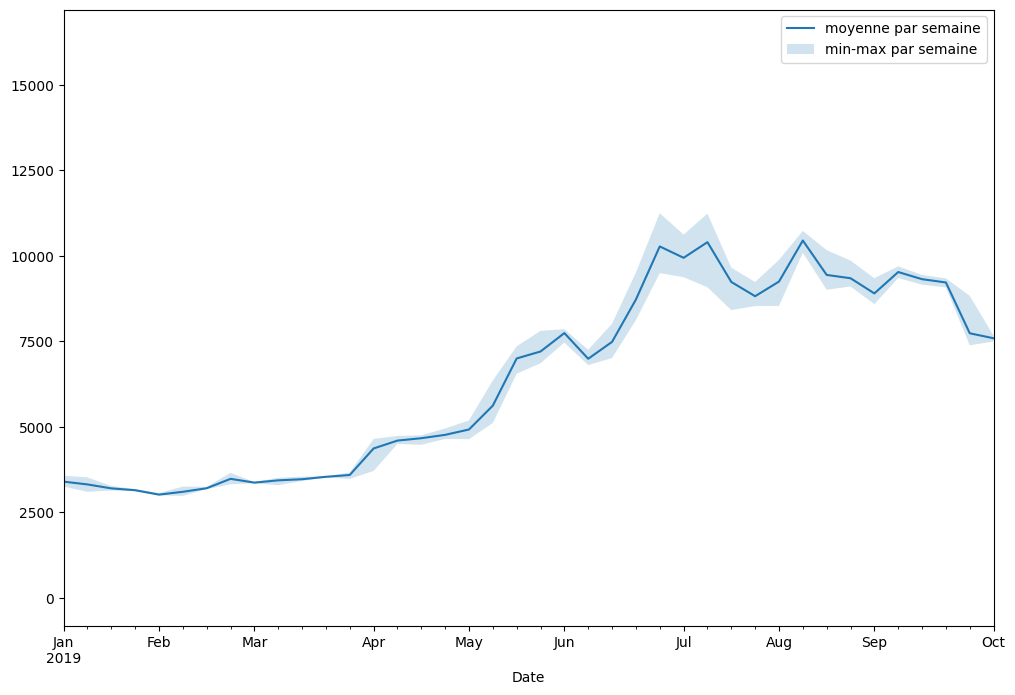

In [26]:
m = bitcoin['Close'].resample('W').agg(['mean', 'std', 'min', 'max'])
plt.figure(figsize=(12, 8))
m['mean']['2019'].plot(label='moyenne par semaine')
plt.fill_between(m.index, m['max'], m['min'], alpha=0.2, label='min-max par semaine')

plt.legend()
plt.show()


<Axes: xlabel='Date'>

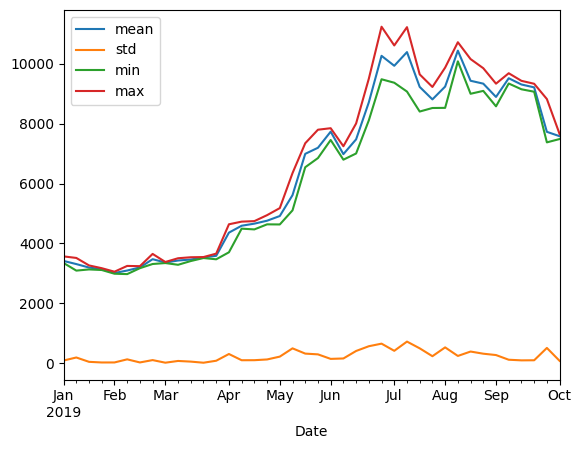

In [27]:
bitcoin.loc['2019', 'Close'].resample('W').agg(['mean', 'std', 'min', 'max']).plot()


## 4. Moving Average (Rolling) et EWM

## Moving Average (Moyenne mobile)

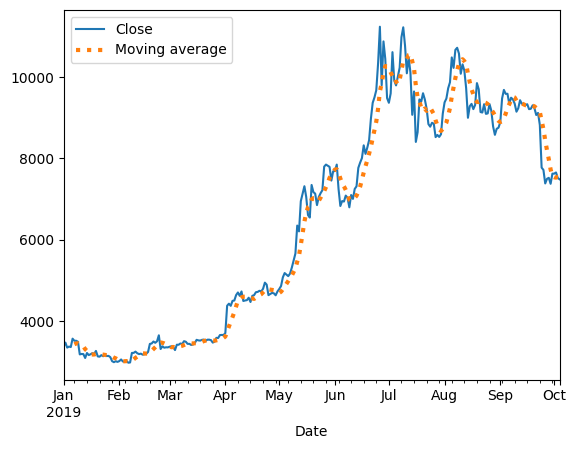

In [28]:
bitcoin.loc['2019', 'Close'].plot()
bitcoin.loc['2019', 'Close'].rolling(window=7).mean().plot(label='Moving average', lw=3, ls=':')
plt.legend()


## Exponential Weighted Average (Moyenne mobile exponentielle)

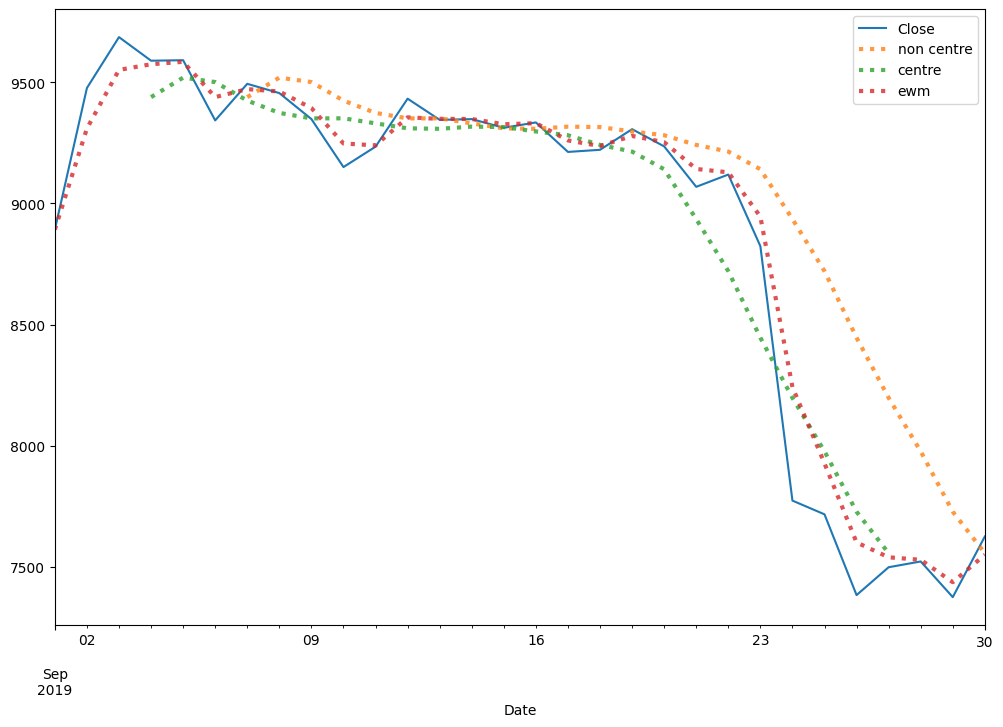

In [29]:
plt.figure(figsize=(12, 8))
bitcoin.loc['2019-09', 'Close'].plot()
bitcoin.loc['2019-09', 'Close'].rolling(window=7).mean().plot(label='non centre', lw=3, ls=':', alpha=0.8)
bitcoin.loc['2019-09', 'Close'].rolling(window=7, center=True).mean().plot(label='centre', lw=3, ls=':', alpha=0.8)
bitcoin.loc['2019-09', 'Close'].ewm(alpha=0.6).mean().plot(label='ewm', lw=3, ls=':', alpha=0.8)
plt.legend()
plt.show()


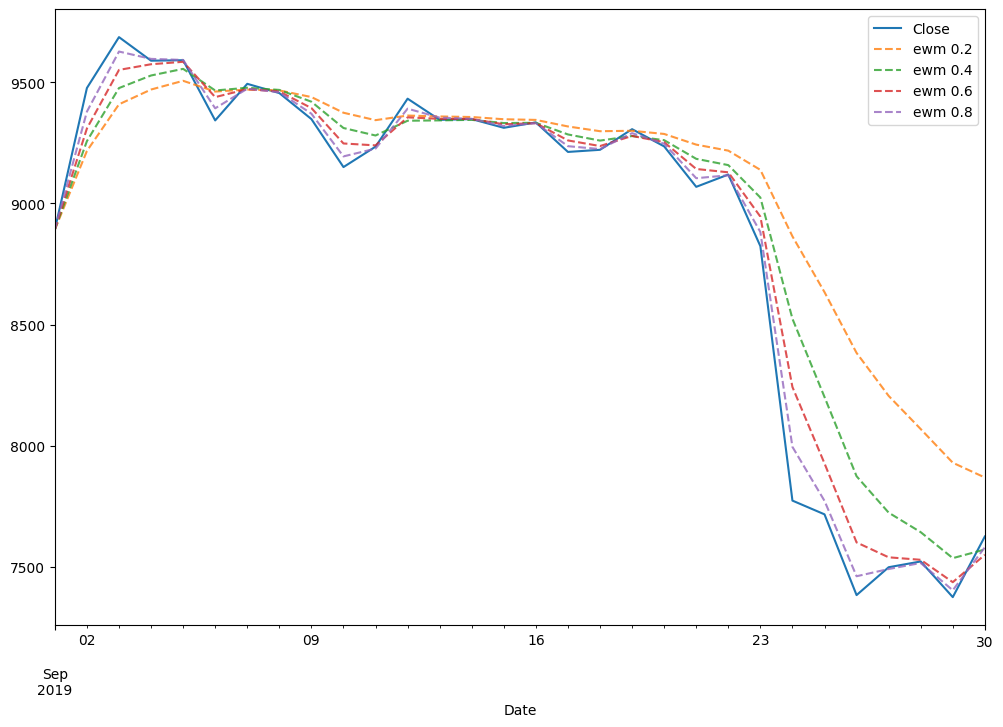

In [30]:
plt.figure(figsize=(12, 8))
bitcoin.loc['2019-09', 'Close'].plot()
for i in np.arange(0.2, 1, 0.2):
    bitcoin.loc['2019-09', 'Close'].ewm(alpha=i).mean().plot(label=f'ewm {i:.1f}', ls='--', alpha=0.8)
plt.legend()
plt.show()


## 5. Comparaison de 2 série temporelles = Assembler des Datasets

In [31]:
ethereum = pd.read_csv('Dataset/ETH-EUR.csv', index_col='Date', parse_dates=True)
print(ethereum.shape)
ethereum.head(3)


(1520, 6)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-08-07,0.593,20.000,0.5930,2.56,2.56,15200
2015-08-08,2.560,2.598,0.5616,0.65,0.65,32816
2015-08-09,0.650,0.800,0.5235,0.70,0.70,4041


<Axes: xlabel='Date'>

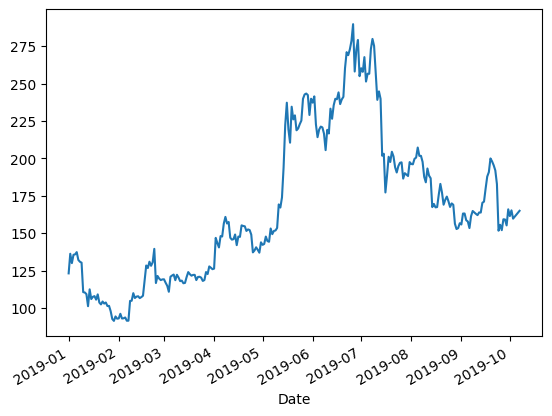

In [32]:
ethereum.loc['2019']['Close'].plot()


In [33]:
btc_eth = pd.merge(bitcoin, ethereum, on='Date', how='inner', suffixes=('_btc', '_eth'))
print(bitcoin.shape)
print(ethereum.shape)
print(btc_eth.shape)
btc_eth.head(3)


(2923, 6)
(1520, 6)
(1519, 12)


,Open_btc,High_btc,Low_btc,Close_btc,Adj Close_btc,Volume_btc,Open_eth,High_eth,Low_eth,Close_eth,Adj Close_eth,Volume_eth
Date,,,,,,,,,,,,
2015-08-07,255.710007,258.880005,253.639999,256.250000,256.250000,1446808,0.593,20.000,0.5930,2.56,2.56,15200
2015-08-08,256.250000,257.029999,239.279999,240.199997,240.199997,1426996,2.560,2.598,0.5616,0.65,0.65,32816
2015-08-09,240.199997,246.110001,239.039993,243.910004,243.910004,797790,0.650,0.800,0.5235,0.70,0.70,4041


<Axes: xlabel='Date'>

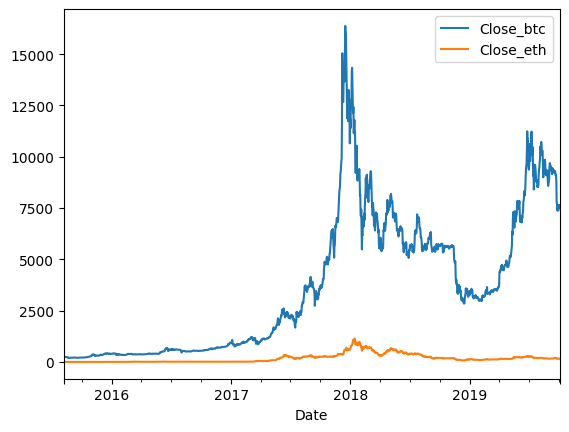

In [34]:
# btc_eth.loc["2015":, "Close_btc"].plot()
# btc_eth.loc["2015":]["Close_eth"].plot()
btc_eth.loc[:, ["Close_btc" , "Close_eth"]].plot()


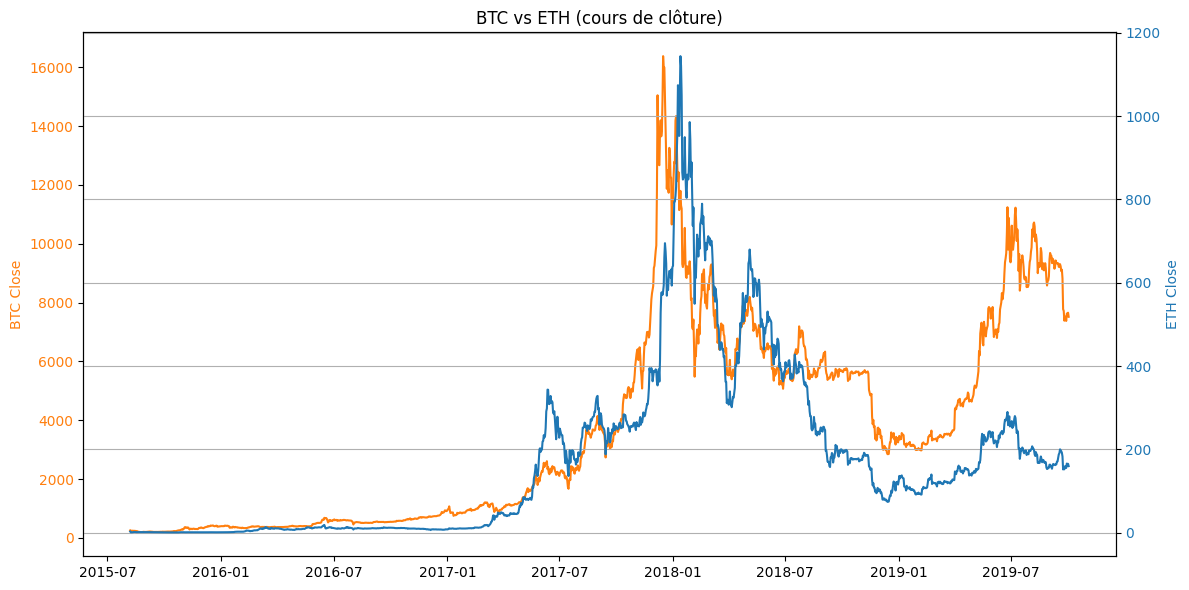

In [35]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe de gauche pour BTC
ax1.plot(btc_eth.index, btc_eth["Close_btc"], color="tab:orange", label="BTC")
ax1.set_ylabel("BTC Close", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:orange")

# Axe de droite pour ETH
ax2 = ax1.twinx()
ax2.plot(btc_eth.index, btc_eth["Close_eth"], color="tab:blue", label="ETH")
ax2.set_ylabel("ETH Close", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Titre et grille
plt.title("BTC vs ETH (cours de clôture)")
fig.tight_layout()
plt.grid()
plt.show()


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

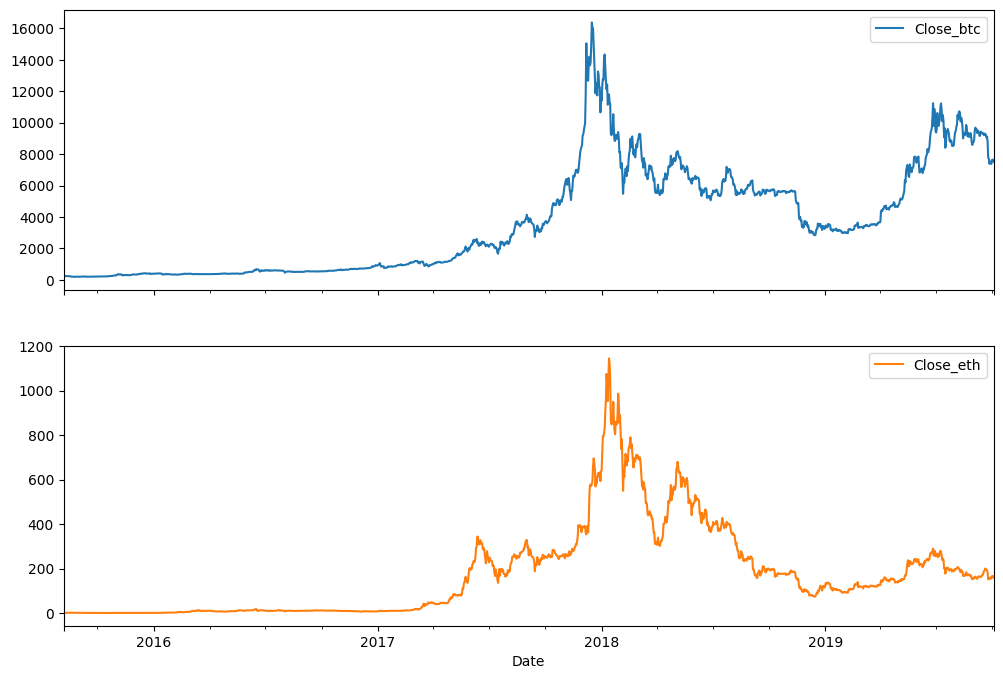

In [36]:
btc_eth.loc[:, ["Close_btc", "Close_eth"]].plot(subplots=True, figsize=(12, 8))


In [37]:
btc_eth.loc[:, ["Close_btc", "Close_eth"]].describe()


,Close_btc,Close_eth
count,1519.000000,1519.000000
mean,3666.089495,174.803159
std,3394.312040,205.305225
min,186.009995,0.382800
25%,555.960022,9.987000
50%,3090.370117,122.169998
75%,5829.515137,252.495003
max,16376.299805,1144.050049


In [38]:
btc_eth.loc[:, ["Close_btc", "Close_eth"]].corr()


,Close_btc,Close_eth
Close_btc,1.000000,0.791416
Close_eth,0.791416,1.000000


## 6. Exercice et Solution

In [39]:
btc = bitcoin.copy()


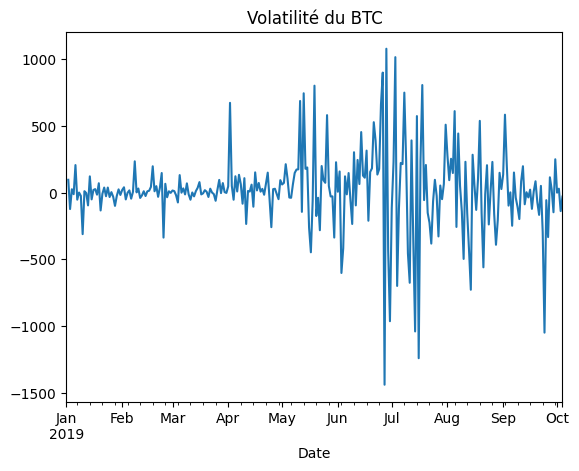

In [40]:
btc.loc["2019":, "Close"].diff().plot()
plt.title('Volatilité du BTC')
plt.show()


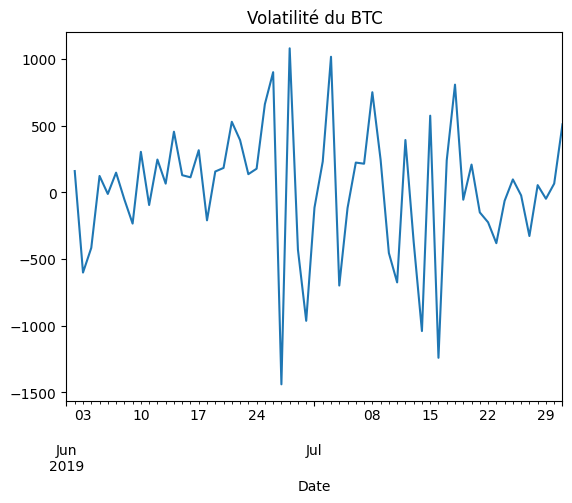

In [41]:
btc.loc["2019-06":'2019-07', "Close"].diff().plot()
plt.title("Volatilité du BTC")
plt.show()


In [42]:
btc.tail(3)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-10-02,7625.560059,7663.270020,7489.770020,7655.250000,7655.250000,51871334
2019-10-03,7655.250000,7685.930176,7379.220215,7516.790039,7516.790039,49437308
2019-10-04,7514.477051,7512.555176,7424.196289,7487.083496,7487.083496,12212041728


In [43]:
btc.loc["2019", "Close"].head(3)


Date
2019-01-01    3372.090088
2019-01-02    3468.399902
2019-01-03    3345.330078
Name: Close, dtype: float64

## Stratégie de la Tortue

In [44]:
data = bitcoin.copy()
data['Buy'] = np.zeros(len(data))
data['Sell'] = np.zeros(len(data))


In [45]:
data['RollingMax'] = data['Close'].shift(1).rolling(window=28).max()
data['RollingMin'] = data['Close'].shift(1).rolling(window=28).min()
data.loc[data['RollingMax'] < data['Close'], 'Buy'] = 1
data.loc[data['RollingMin'] > data['Close'], 'Sell'] = -1


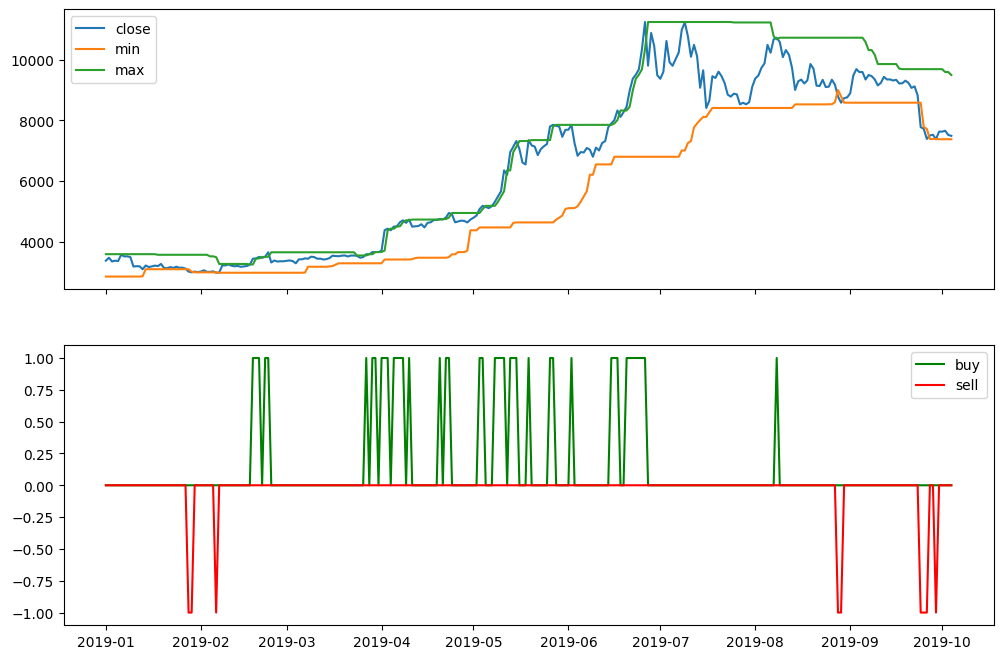

In [46]:
start ='2019'
end='2019'
fig, ax = plt.subplots(2, figsize=(12, 8), sharex=True)
#plt.figure(figsize=(12, 8))
#plt.subplot(211)
ax[0].plot(data['Close'][start:end])
ax[0].plot(data['RollingMin'][start:end])
ax[0].plot(data['RollingMax'][start:end])
ax[0].legend(['close', 'min', 'max'])
ax[1].plot(data['Buy'][start:end], c='g')
ax[1].plot(data['Sell'][start:end], c='r')
ax[1].legend(['buy', 'sell'])

# plt.tight_layout()
plt.show()


In [47]:
%pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [76]:
import yfinance as yf

df = yf.download("BTC-USD")
df.to_csv("BTC.csv")

df.sample(5)


C:\Users\utilisateur\AppData\Local\temp\ipykernel_5032\2071498697.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-11-19,91465.992188,92946.164062,88526.828125,92946.164062,80350354656
2025-11-01,110064.015625,110574.898438,109372.953125,109558.625000,25871668762
2025-11-02,110639.625000,111167.312500,109523.453125,110064.429688,34284209459
2025-11-17,92093.875000,95928.367188,91214.757812,94180.875000,94186165724
2025-11-22,84648.359375,85503.007812,83490.898438,85098.562500,40793099246


[*********************100%***********************]  2 of 2 completed


Price            Close                High                 Low                Open            Volume        
Ticker         BTC-USD ETH-USD     BTC-USD ETH-USD     BTC-USD ETH-USD     BTC-USD ETH-USD   BTC-USD ETH-USD
Date                                                                                                        
2014-09-17  457.334015     NaN  468.174011     NaN  452.421997     NaN  465.864014     NaN  21056800     NaN
2014-09-18  424.440002     NaN  456.859985     NaN  413.104004     NaN  456.859985     NaN  34483200     NaN
2014-09-19  394.795990     NaN  427.834991     NaN  384.532013     NaN  424.102997     NaN  37919700     NaN
2014-09-20  408.903992     NaN  423.295990     NaN  389.882996     NaN  394.673004     NaN  36863600     NaN
2014-09-21  398.821014     NaN  412.425995     NaN  393.181000     NaN  408.084991     NaN  26580100     NaN


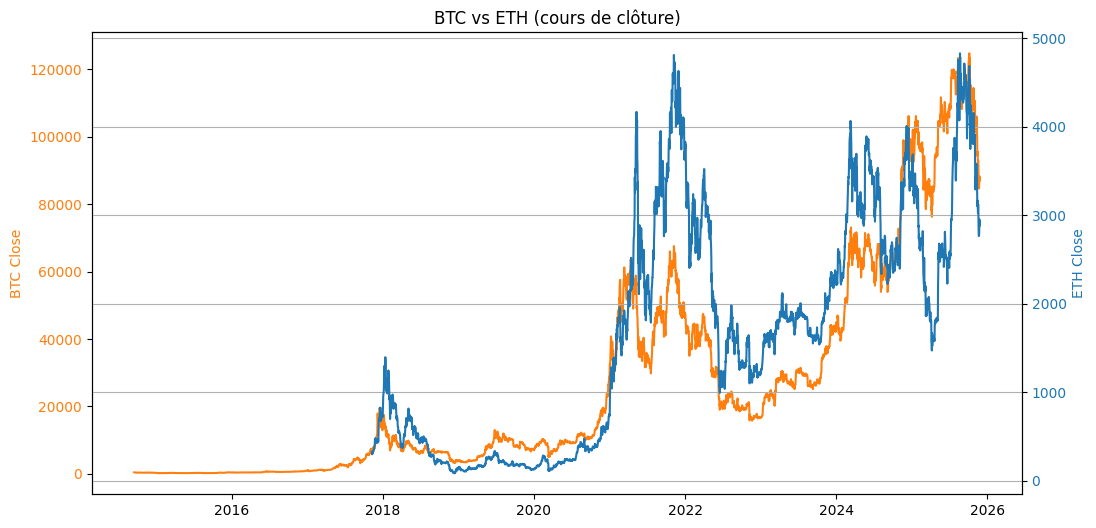

In [78]:
import yfinance as yf
import matplotlib.pyplot as plt

# Télécharger plusieurs tickers
tickers = ["BTC-USD", "ETH-USD"]
# df = yf.download(tickers, start="2019-01-01", end="2025-11-25")
df = yf.download(tickers, period="max", auto_adjust=True) # True default

# Aperçu des données
print(df.head())

# Tracer les cours de clôture
fig, ax1 = plt.subplots(figsize=(12, 6))


# Axe de gauche pour BTC
ax1.plot(df.index, df["Close"]["BTC-USD"], color="tab:orange", label="BTC")
ax1.set_ylabel("BTC Close", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:orange")

# Axe de droite pour ETH
ax2 = ax1.twinx()
ax2.plot(df.index, df["Close"]["ETH-USD"], color="tab:blue", label="ETH")
ax2.set_ylabel("ETH Close", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Titre et grille
plt.title("BTC vs ETH (cours de clôture)")

plt.grid()
plt.show()


In [ ]:
print(df.columns)


MultiIndex([( 'Close', 'BTC-USD'),
            ( 'Close', 'ETH-USD'),
            (  'High', 'BTC-USD'),
            (  'High', 'ETH-USD'),
            (   'Low', 'BTC-USD'),
            (   'Low', 'ETH-USD'),
            (  'Open', 'BTC-USD'),
            (  'Open', 'ETH-USD'),
            ('Volume', 'BTC-USD'),
            ('Volume', 'ETH-USD')],
           names=['Price', 'Ticker'])


In [79]:
df.shape


(4088, 10)

In [80]:
df['Close']['ETH-USD'].tail


<bound method NDFrame.tail of Date
2014-09-17            NaN
2014-09-18            NaN
2014-09-19            NaN
2014-09-20            NaN
2014-09-21            NaN
                 ...     
2025-11-21    2765.699219
2025-11-22    2767.607422
2025-11-23    2801.676025
2025-11-24    2952.713379
2025-11-25    2885.537354
Freq: D, Name: ETH-USD, Length: 4088, dtype: float64>

In [82]:
df['Close'].sample(5)


Ticker,BTC-USD,ETH-USD
Date,,
2020-03-03,8787.786133,224.479630
2016-06-06,585.536987,NaN
2025-02-25,88736.171875,2493.592529
2023-08-27,26089.693359,1657.513062
2018-11-11,6411.270020,211.339996


In [93]:
df["Close"].describe()


Ticker,BTC-USD,ETH-USD
count,4088.000000,2939.000000
mean,26299.303801,1668.394108
std,31241.069253,1295.257260
min,178.102997,84.308296
25%,2601.902466,341.797363
50%,10579.554688,1634.326416
75%,41462.885742,2632.481567
max,124752.531250,4831.348633


In [ ]:
df["Close"].iloc[-1]


Ticker
BTC-USD    87044.328125
ETH-USD     2885.537354
Name: 2025-11-25 00:00:00, dtype: float64

In [ ]:
10/3, round(10 / 3, 15)


(3.3333333333333335, 3.333333333333333)